In [1]:
!pip install transformers
!pip install openpyxl

In [2]:
import warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
import transformers
import torch
import os
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import DistilBertTokenizer, DistilBertModel
import logging
logging.basicConfig(level=logging.ERROR)

In [3]:
fos_train_df = pd.read_excel('/content/Train_Set_WLabels.xlsx')
fos_test_df = pd.read_excel('/content/Test_Set_WLabels.xlsx')

In [4]:
fos_train_df = fos_train_df.rename(columns={"Is FOS": "is_fos"})
fos_test_df = fos_test_df.rename(columns={"Is FOS": "is_fos"})

In [5]:
from transformers import pipeline #cbert

unmasker = pipeline('fill-mask', model='GianTan/CBERTo')
unmasker("Hello I'm a [MASK] model.")

Device set to use cuda:0


[{'score': 0.017744773998856544,
  'token': 457,
  'token_str': 'sentence',
  'sequence': "hello i'm a sentence model."},
 {'score': 0.013290436938405037,
  'token': 1461,
  'token_str': 'given',
  'sequence': "hello i'm a given model."},
 {'score': 0.010848677717149258,
  'token': 4051,
  'token_str': 'story',
  'sequence': "hello i'm a story model."},
 {'score': 0.009323697537183762,
  'token': 3482,
  'token_str': 'text',
  'sequence': "hello i'm a text model."},
 {'score': 0.00910557247698307,
  'token': 1241,
  'token_str': 'list',
  'sequence': "hello i'm a list model."}]

In [6]:
tokenizer = DistilBertTokenizer.from_pretrained('GianTan/CBERTo',truncation=True, do_lower_case=False)
model = DistilBertModel.from_pretrained("GianTan/CBERTo")

In [7]:
input = tokenizer('Murag mag bata nis Gian.', return_tensors='pt')
input

{'input_ids': tensor([[   2,    1,  223,  770, 4073,    1,   20,    3]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [8]:
output = model(input_ids=input['input_ids'], attention_mask=input['attention_mask'])
output

BaseModelOutput(last_hidden_state=tensor([[[ 1.8262, -2.2653, -0.2164,  ..., -0.3576,  0.7976,  0.1592],
         [ 0.1707, -0.2825,  0.3335,  ...,  0.9750,  1.2135,  1.2772],
         [-1.1447,  0.3449, -0.0371,  ..., -0.7239,  1.3636, -1.6204],
         ...,
         [-1.5133, -1.6592,  0.0718,  ...,  0.8302,  1.3838, -0.4917],
         [-1.5697, -0.8247, -2.1634,  ..., -0.4481,  0.8399, -1.4725],
         [-1.5261, -0.4124, -0.6070,  ...,  0.5469, -1.1056, -0.0184]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [9]:
# Sections of config
# Defining some key variables that will be used later on in the training
MAX_LEN = 256
TRAIN_BATCH_SIZE = 128
VALID_BATCH_SIZE = 128
EPOCHS = 14
LEARNING_RATE = 4e-05

In [10]:
class FOS_Classification(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.Usage
        self.targets = self.data.is_fos
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            pad_to_max_length=True,
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]


        return {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

In [11]:
training_set = FOS_Classification(fos_train_df, tokenizer, MAX_LEN)
testing_set = FOS_Classification(fos_test_df, tokenizer, MAX_LEN)

In [12]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

In [13]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [14]:
class BertClass(torch.nn.Module):
    def __init__(self):
        super(BertClass, self).__init__()
        self.l1 = DistilBertModel.from_pretrained('GianTan/CBERTo')
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.3)

        self.pre_classifier2 = torch.nn.Linear(768, 768)
        self.dropout2 = torch.nn.Dropout(0.3)

        self.classifier = torch.nn.Linear(768,1)

    def forward(self, input_ids, attention_mask, token_type_ids):
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        pooler = hidden_state[:, 0]
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        pooler = self.pre_classifier2(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout2(pooler)


        output = self.classifier(pooler)
        return output.squeeze(1)


model = BertClass()
model.to(device)



BertClass(
  (l1): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(256, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_feat

In [15]:
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [16]:
optimizer = torch.optim.Adam(params =  model.parameters(), lr=LEARNING_RATE)

In [17]:
def train(epoch):
    model.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['ids'].to(device, dtype = torch.long)
        mask = data['mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        outputs = model(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        if _%5000==0:
            print(f'Epoch: {epoch}, Loss:  {loss.item()}')

        loss.backward()
        optimizer.step()

In [18]:
for epoch in range(EPOCHS):
    train(epoch)

0it [00:00, ?it/s]

Epoch: 0, Loss:  0.7084692120552063


8it [00:16,  2.08s/it]
1it [00:02,  2.20s/it]

Epoch: 1, Loss:  0.5628543496131897


8it [00:17,  2.22s/it]
1it [00:02,  2.26s/it]

...

8it [00:19,  2.44s/it]
1it [00:02,  2.49s/it]

Epoch: 12, Loss:  0.0025346935726702213


8it [00:19,  2.44s/it]
1it [00:02,  2.48s/it]

Epoch: 13, Loss:  0.00671275844797492


8it [00:19,  2.43s/it]


In [19]:

def test_model(item):
  input_text = item
  encoded_text = tokenizer.encode_plus(
      input_text,
      None,
      add_special_tokens=True,
      max_length=MAX_LEN,
      pad_to_max_length=True,
      return_token_type_ids=True
  )

  # Convert the input to tensors
  input_ids = torch.tensor(encoded_text['input_ids']).unsqueeze(0)
  input_mask = torch.tensor(encoded_text['attention_mask']).unsqueeze(0)
  segment_ids = torch.tensor(encoded_text['token_type_ids']).unsqueeze(0)

  # Move tensors to the device
  input_ids = input_ids.to(device)
  input_mask = input_mask.to(device)
  segment_ids = segment_ids.to(device)

  # Make predictions
  with torch.no_grad():
      outputs = model(input_ids, input_mask, segment_ids)

  # Apply sigmoid activation function
  outputs = torch.sigmoid(outputs)

  # Convert the outputs to numpy array
  outputs = outputs.cpu().detach().numpy()

  return outputs

In [20]:
def validation(testing_loader):
    model.eval()
    fin_targets=[]
    fin_outputs=[]

    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['ids'].to(device, dtype = torch.long)
            mask = data['mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)
            fin_targets.extend(targets.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

    return fin_outputs, fin_targets


In [21]:
outputs, targets = validation(testing_loader)

final_outputs = np.array(outputs) >= 0.9

print(final_outputs)
print(targets)

2it [00:03,  1.64s/it]

[False False False False  True  True False False  True False  True False
  True  True False False False  True  True False  True  True  True  True
  True False False False  True False  True  True False False  True False
  True  True  True False  True False False False  True False False  True
 False  True False False False False  True False False False False False
 False  True  True  True  True  True False False False  True  True False
  True  True False  True  True False False  True  True False False  True
  True False False  True  True False  True False  True  True  True False
  True False  True False False False False False False False False  True
  True False  True False False False  True  True  True  True False  True
  True False  True False  True  True False  True  True False  True False
 False  True  True  True  True  True False False  True False False False
 False  True False  True False  True False  True False  True  True  True
 False False False  True  True  True False False  T

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

y_pred = np.array(targets)
y_true = np.array(final_outputs)

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy Score: {accuracy:.6f}')

precision = precision_score(y_true, y_pred)
print(f'Precision Score: {precision:.6f}')

recall = recall_score(y_true, y_pred)
print(f'Recall Score: {recall:.6f}')

score_dat = f1_score(y_true, y_pred)
print(f'F1 Score: {score_dat:.6f}')


Accuracy Score: 0.909836
Precision Score: 0.901639
Recall Score: 0.916667
F1 Score: 0.909091


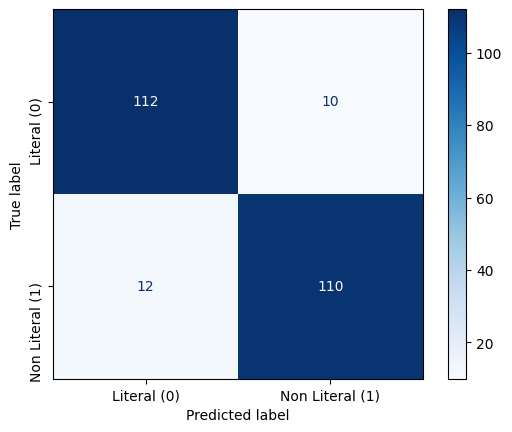

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming targets are the true labels and final_outputs are the predicted labels
y_true = np.array(targets)
y_pred = np.array(final_outputs)

class_labels = ["Literal (0)", "Non Literal (1)"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")  # You can change the colormap if needed

plt.yticks(rotation=90)

plt.show()

In [25]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define directory inside Google Drive
drive_checkpoint_dir = "/content/drive/My Drive/CBERT_Checkpoints"
os.makedirs(drive_checkpoint_dir, exist_ok=True)

def save_checkpoint(epoch, model, optimizer, loss):
    checkpoint_path = f"{drive_checkpoint_dir}/checkpoint_epoch_{epoch}.pth"

    # Save the checkpoint to Google Drive
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }, checkpoint_path)

    print(f"Checkpoint saved at: {checkpoint_path}")

def train(epoch):
    model.train()
    total_loss = 0
    for _, data in tqdm(enumerate(training_loader, 0)):
        ids = data['ids'].to(device, dtype=torch.long)
        mask = data['mask'].to(device, dtype=torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype=torch.long)
        targets = data['targets'].to(device, dtype=torch.float)

        outputs = model(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        total_loss += loss.item()

        if _ % 5000 == 0:
            print(f'Epoch: {epoch}, Step: {_}, Loss: {loss.item()}')

        loss.backward()
        optimizer.step()

    #  Save checkpoint after each epoch (to Google Drive)
    save_checkpoint(epoch, model, optimizer, total_loss / len(training_loader))

#  Run training with checkpointing
for epoch in range(EPOCHS):
    train(epoch)

Mounted at /content/drive


1it [00:01,  1.09s/it]

Epoch: 0, Step: 0, Loss: 0.0018264141399413347


8it [00:18,  2.30s/it]


✅ Checkpoint saved at: /content/drive/My Drive/CBERT_Checkpoints/checkpoint_epoch_0.pth


...

✅ Checkpoint saved at: /content/drive/My Drive/CBERT_Checkpoints/checkpoint_epoch_12.pth


1it [00:01,  1.04s/it]

Epoch: 13, Step: 0, Loss: 0.000445310230134055


8it [00:18,  2.34s/it]


✅ Checkpoint saved at: /content/drive/My Drive/CBERT_Checkpoints/checkpoint_epoch_13.pth
